# House Price Prediction

## Load Module / Libraries 

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import calendar 

from sklearn.preprocessing import LabelEncoder
from pandas.api.types import CategoricalDtype

from sklearn.preprocessing import StandardScaler


### Read and Set the path

In [23]:
path_test_data = r"C:\Users\M irfan shahid\house_price_predict\dataset\test.csv"
path_train_data = r"C:\Users\M irfan shahid\house_price_predict\dataset\train.csv"

df_train = pd.read_csv(path_train_data)
df_test = pd.read_csv(path_test_data)

### We checked the shape of data

In [24]:
print("Shape of train data: ", df_train.shape)
print("Shape of test data: ", df_test.shape)

Shape of train data:  (1460, 81)
Shape of test data:  (1459, 80)


### I want to check all colums and rows 

In [25]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

### Now We use the head(Function) to see the DataFrame

In [26]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [27]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Data Integration

In [28]:
df = pd.concat([ df_train, df_test])

print("The Data After Concat DF: ", df.shape)

The Data After Concat DF:  (2919, 81)


In [29]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [30]:
df.tail(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


## Get The Brife Info Of Dataset

In [31]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

In [32]:
2919 -10

2909

In [33]:
float_features = df.select_dtypes(include = ["float64"]).columns
print("Total number of float features : ", len(float_features)) ## use len of : this is more readable insted .shape[0]

print("float feature names: ", float_features.tolist())

Total number of float features :  12
float feature names:  ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']


In [34]:
int_features = df.select_dtypes(include = ["int64"]).columns
print("Total number of int features : ", int_features.shape[0])

print ("float features names", int_features.tolist())

Total number of int features :  26
float features names ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [35]:
cat_feature = df.select_dtypes(include = ["object"]).columns
print("Total number of object features : " , len(cat_feature))

print("object features names" , cat_feature.tolist())

Total number of object features :  43
object features names ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## Get The Statical Information Of Numerical Feature

In [36]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [37]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

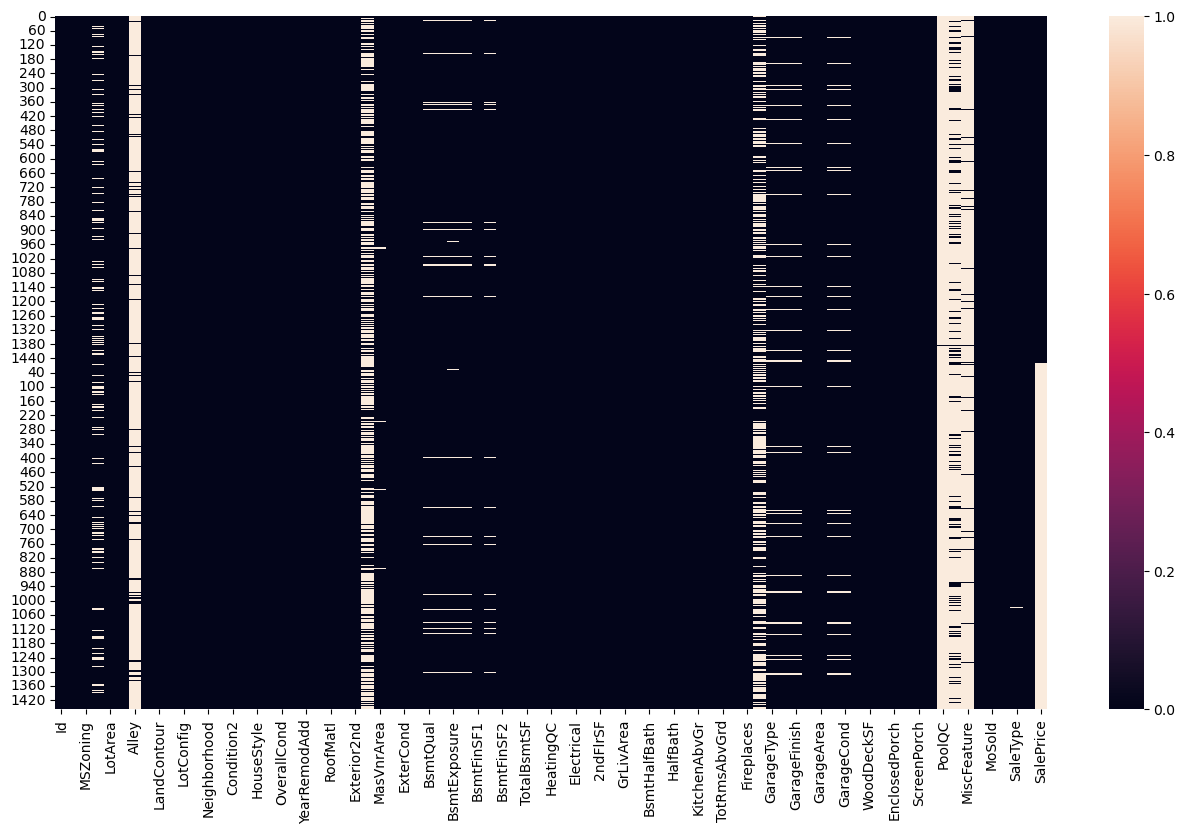

In [38]:
plt.figure(figsize = (16, 9))
sns.heatmap(df.isnull())
plt.savefig("save_EDA_images/heatmap_of_null_values.png")

In [39]:
df = df.set_index("Id")

## Get The Null Value Percentage For Every Features 

In [40]:
null_value_count = df.isnull().sum()
null_value_count

MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
Alley            2721
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType       1766
MasVnrArea         23
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           81
BsmtCond           82
BsmtExposure       82
BsmtFinType1       79
BsmtFinSF1          1
BsmtFinType2       80
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea 

In [41]:
null_value_percentage = df.isnull().sum()/len(df)*100           # we use percentage formula here
null_value_percentage

MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
Street            0.000000
Alley            93.216855
LotShape          0.000000
LandContour       0.000000
Utilities         0.068517
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.034258
Exterior2nd       0.034258
MasVnrType       60.500171
MasVnrArea        0.787941
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.774923
BsmtCond          2.809181
BsmtExposure      2.809181
BsmtFinType1      2.706406
BsmtFinSF1        0.034258
BsmtFinType2      2.740665
BsmtFinSF2        0.034258
BsmtUnfSF         0.034258
T

## Missing value Imputation 

In [42]:
missing_value_feat = null_value_percentage[null_value_percentage > 0]
print("total = ", len(missing_value_feat))
missing_value_feat

total =  35


MSZoning         0.137033
LotFrontage     16.649538
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
MasVnrArea       0.787941
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinSF1       0.034258
BsmtFinType2     2.740665
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
Electrical       0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageCars       0.034258
GarageArea       0.034258
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
SalePrice       49.982871
dtype: float64

In [43]:
"""BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665

BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517"""

'BsmtQual         2.774923\nBsmtCond         2.809181\nBsmtExposure     2.809181\nBsmtFinType1     2.706406\nBsmtFinType2     2.740665\n\nBsmtFinSF1       0.034258\nBsmtFinSF2       0.034258\nBsmtUnfSF        0.034258\nTotalBsmtSF      0.034258\nBsmtFullBath     0.068517\nBsmtHalfBath     0.068517'

In [44]:
## missing category values features 
missing_cat_feature = missing_value_feat[missing_value_feat.keys().isin(cat_feature)]
print("total category missing features  = ", len(missing_cat_feature))
print ("---------------------------------")
print(missing_cat_feature)
print("-----")

## missing integer values features 
missing_int_feature = missing_value_feat[missing_value_feat.keys().isin(int_features)]
print("total integer missing features = ", len(missing_int_feature))
print ("---------------------------------")
print(missing_int_feature)
print("-----")

## missing float values features 
missing_float_feature = missing_value_feat[missing_value_feat.keys().isin(float_features)]
print("total float missing features  = ", len(missing_float_feature))
print ("---------------------------------")
print(missing_float_feature)
print("-----")

total category missing features  =  23
---------------------------------
MSZoning         0.137033
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType      60.500171
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665
Electrical       0.034258
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
dtype: float64
-----
total integer missing features =  0
---------------------------------
Series([], dtype: float64)
-----
total float missing features  =  12
---------------------------------
LotFrontage     16.649538
MasVnrArea       0.787941
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
Total

In [45]:
df["MSZoning"].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='MSZoning'>

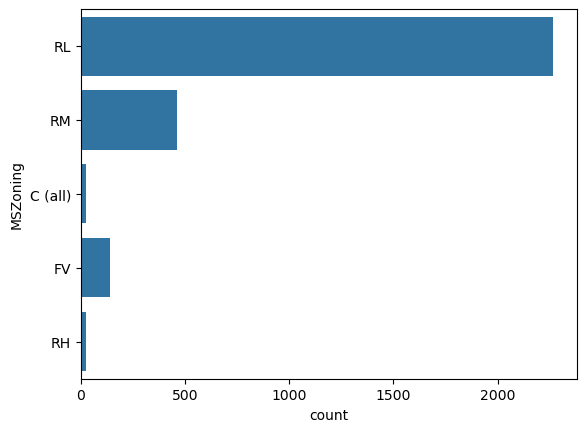

In [46]:
sns.countplot(df["MSZoning"])

## backup of orignal data 

In [47]:
df_mvi = df.copy()
df_mvi.shape

(2919, 80)

In [48]:
## mode of object data types

In [49]:
mszoning_mode = df["MSZoning"].mode()[0]
df_mvi["MSZoning"].replace(np.nan, mszoning_mode,  inplace = True)
df_mvi["MSZoning"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\876550415.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["MSZoning"].replace(np.nan, mszoning_mode,  inplace = True)


np.int64(0)

<Axes: xlabel='count', ylabel='MSZoning'>

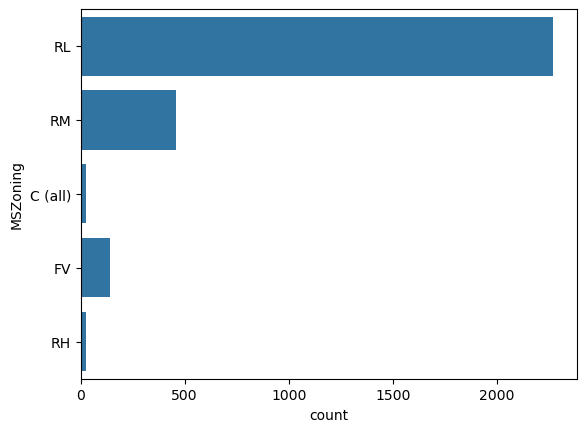

In [50]:
sns.countplot(df_mvi["MSZoning"])

In [51]:
def oldNewcountplot(df, new_df, features):
    plt.subplot(121)
    sns.countplot(df[features])
    plt.title("old")
    plt.subplot(122)
    sns.countplot(df_mvi[features])
    plt.title("new")

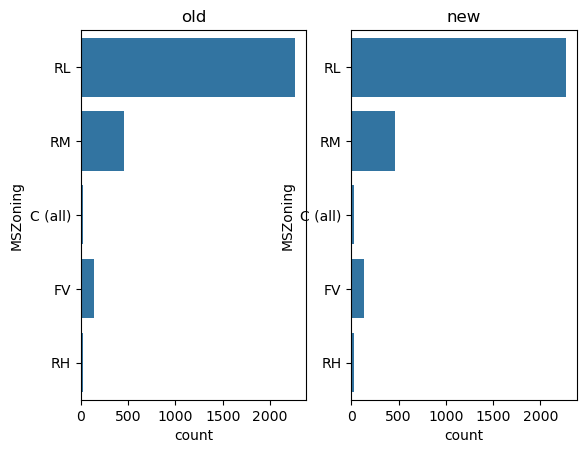

In [52]:
oldNewcountplot(df, df_mvi, "MSZoning")

## handling Alley = 93.216855

In [53]:
alley_cont = "NA"
df_mvi["Alley"].replace(np.nan, alley_cont,  inplace= True)
df_mvi["Alley"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2606729547.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["Alley"].replace(np.nan, alley_cont,  inplace= True)


np.int64(0)

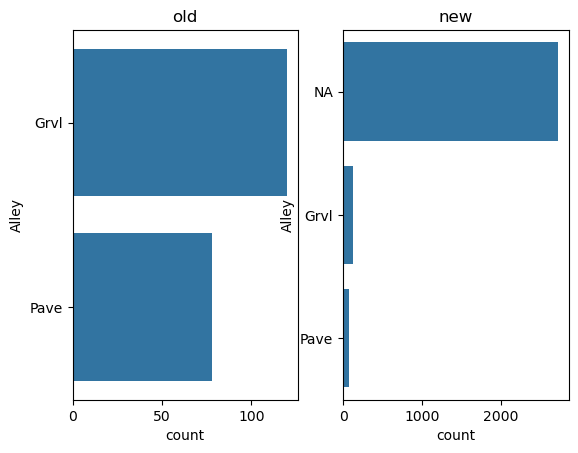

In [54]:
oldNewcountplot(df, df_mvi, "Alley")

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\3859205968.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df)


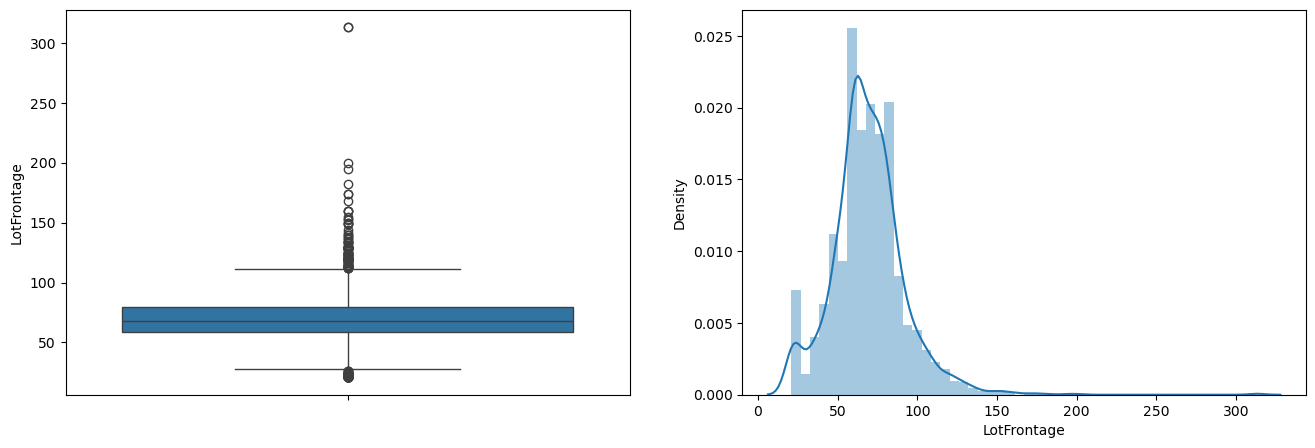

In [55]:
def boxhistplot(df , figsize = (16, 5)):
    plt.figure(figsize = figsize)
    plt.subplot(121)
    sns.boxplot(df)
    plt.subplot(122)
    sns.distplot(df)
boxhistplot(df["LotFrontage"])
    

In [56]:
lotfrontage_median = df["LotFrontage"].median()
lotfrontage_median
df_mvi["LotFrontage"].replace(np.nan, lotfrontage_median,  inplace=True)

df_mvi["LotFrontage"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\73707904.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["LotFrontage"].replace(np.nan, lotfrontage_median,  inplace=True)


np.int64(0)

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\1251270888.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[features])
C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\1251270888.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_mvi[features])


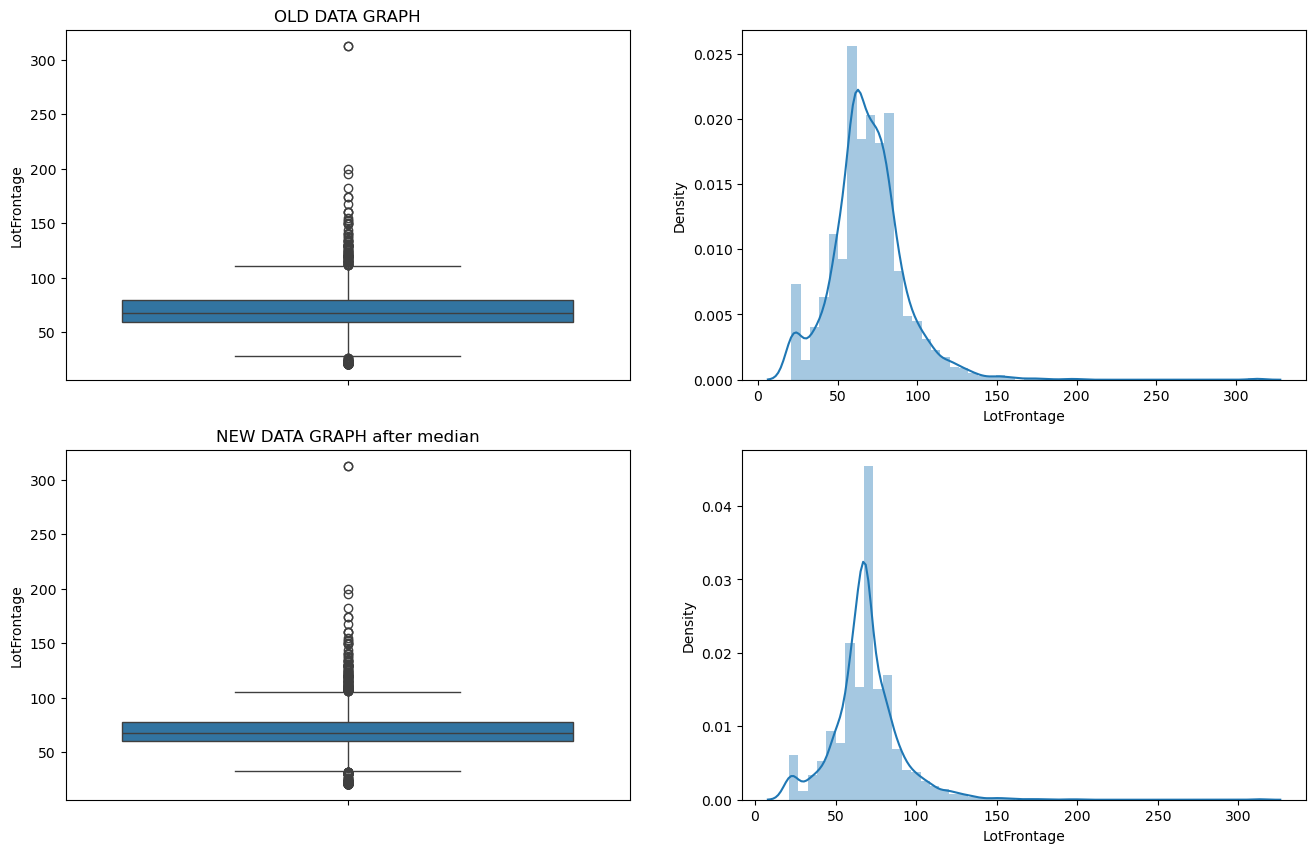

In [57]:
def oldNewboxhistplot(df, df_mvi, features, figsize = (16,10)):
    plt.figure(figsize = figsize)
    plt.subplot(221)
    plt.title("OLD DATA GRAPH")
    sns.boxplot(df[features])
    plt.title("OLD DATA GRAPH")
    plt.subplot(222)
    sns.distplot(df[features])

    plt.subplot(223)
    plt.title("NEW DATA GRAPH after median")
    sns.boxplot(df_mvi[features])
    plt.title("NEW DATA GRAPH after median")
    plt.subplot(224)
    sns.distplot(df_mvi[features])

oldNewboxhistplot(df, df_mvi, "LotFrontage")

## handling Utilities = 0.068517

In [58]:
df["Utilities"].value_counts()

Utilities
AllPub    2916
NoSeWa       1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Utilities'>

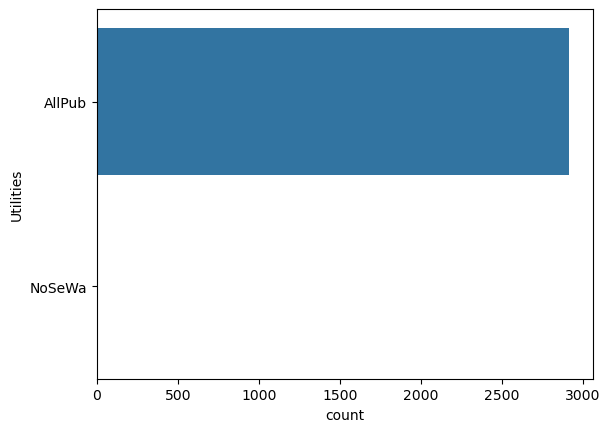

In [59]:
sns.countplot(df["Utilities"])

In [60]:
utilities_mode = df["Utilities"].mode()[0]
df_mvi["Utilities"].replace(np.nan, utilities_mode, inplace = True) 
df_mvi["Utilities"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\181278287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["Utilities"].replace(np.nan, utilities_mode, inplace = True)


np.int64(0)

<Axes: xlabel='count', ylabel='Utilities'>

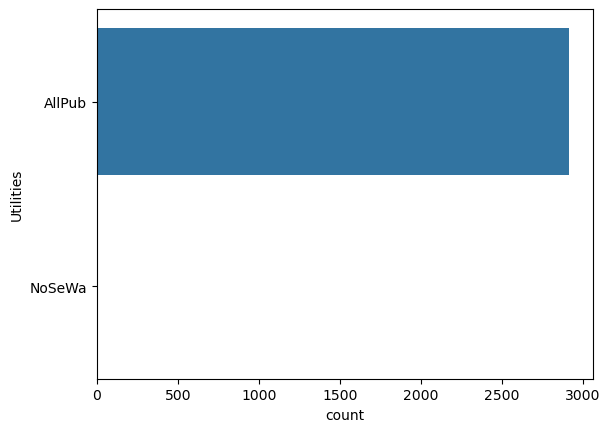

In [61]:
sns.countplot(df_mvi["Utilities"])

## handling Exterior1st AND Exterior2nd 

In [62]:
print(df["Exterior1st"].value_counts())
print("------")
print(df["Exterior2nd"].value_counts())

Exterior1st
VinylSd    1025
MetalSd     450
HdBoard     442
Wd Sdng     411
Plywood     221
CemntBd     126
BrkFace      87
WdShing      56
AsbShng      44
Stucco       43
BrkComm       6
AsphShn       2
Stone         2
CBlock        2
ImStucc       1
Name: count, dtype: int64
------
Exterior2nd
VinylSd    1014
MetalSd     447
HdBoard     406
Wd Sdng     391
Plywood     270
CmentBd     126
Wd Shng      81
BrkFace      47
Stucco       47
AsbShng      38
Brk Cmn      22
ImStucc      15
Stone         6
AsphShn       4
CBlock        3
Other         1
Name: count, dtype: int64


In [63]:
Exterior1st_mode = df["Exterior1st"].mode()[0]
Exterior2nd_mode = df["Exterior2nd"].mode()[0]
df_mvi["Exterior1st"].replace(np.nan, Exterior1st_mode, inplace = True)
df_mvi["Exterior2nd"].replace(np.nan, Exterior2nd_mode, inplace = True)
print("E1st is null: ", df_mvi["Exterior1st"].isnull().sum())
print("E2nd is null: ", df_mvi["Exterior2nd"].isnull().sum())

E1st is null:  0
E2nd is null:  0


C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2592717022.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["Exterior1st"].replace(np.nan, Exterior1st_mode, inplace = True)
C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2592717022.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

## Handling MasVnrType = 60.500171

In [64]:
df["MasVnrType"].value_counts()

MasVnrType
BrkFace    879
Stone      249
BrkCmn      25
Name: count, dtype: int64

In [65]:
masvnrtype_mode = df["MasVnrType"].mode()[0]
df_mvi["MasVnrType"].replace(np.nan, masvnrtype_mode, inplace = True) 
print("null value is: ", df_mvi["MasVnrType"].isnull().sum())

null value is:  0


C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\4260639427.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["MasVnrType"].replace(np.nan, masvnrtype_mode, inplace = True)


In [66]:
masvnrtype_mode 

'BrkFace'

## Handling MasVnrArea = 0.787941

In [67]:
df_mvi["MasVnrArea"].value_counts().head()

MasVnrArea
0.0      1738
120.0      15
176.0      13
200.0      13
216.0      12
Name: count, dtype: int64

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\3859205968.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df)


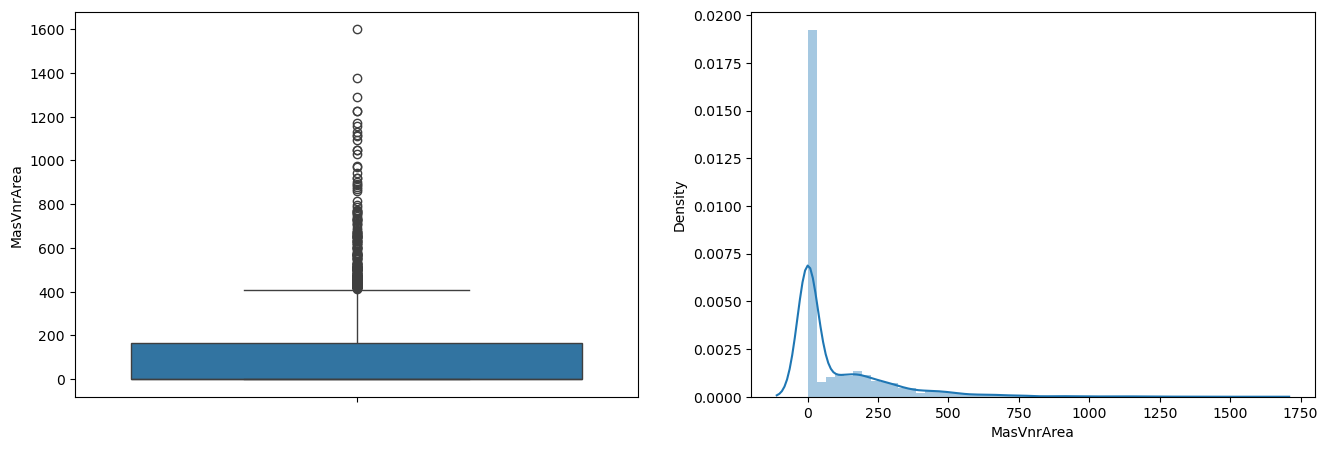

In [68]:
boxhistplot(df["MasVnrArea"])

In [69]:
masvnrarea_cont = 0
df_mvi["MasVnrArea"].replace(np.nan, masvnrarea_cont, inplace = True) 
print(" value is constant: ", df["MasVnrArea"].isnull().sum())

 value is constant:  23


C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\531137325.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["MasVnrArea"].replace(np.nan, masvnrarea_cont, inplace = True)


In [70]:
df_mvi["MasVnrArea"].value_counts().head() 

MasVnrArea
0.0      1761
120.0      15
176.0      13
200.0      13
216.0      12
Name: count, dtype: int64

## Handling BsmtQual = 2.774923 BsmtCond = 2.809181

In [71]:
df_mvi["BsmtQual"].value_counts()

BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64

In [72]:
df_mvi["BsmtCond"].value_counts()

BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64

In [73]:
bsmtcond_const = "NA"
df_mvi["BsmtCond"].replace(np.nan, bsmtcond_const,  inplace= True)
df_mvi["BsmtCond"].isnull().sum()
print("------")
bsmtqual_const = "NA"
df_mvi["BsmtQual"].replace(np.nan, bsmtqual_const,  inplace= True)
df_mvi["BsmtQual"].isnull().sum()

------


C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\1818067386.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["BsmtCond"].replace(np.nan, bsmtcond_const,  inplace= True)
C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\1818067386.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

np.int64(0)

In [74]:
df_mvi["BsmtCond"].value_counts()

BsmtCond
TA    2606
Gd     122
Fa     104
NA      82
Po       5
Name: count, dtype: int64

In [75]:
df_mvi["BsmtQual"].value_counts()

BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
NA      81
Name: count, dtype: int64

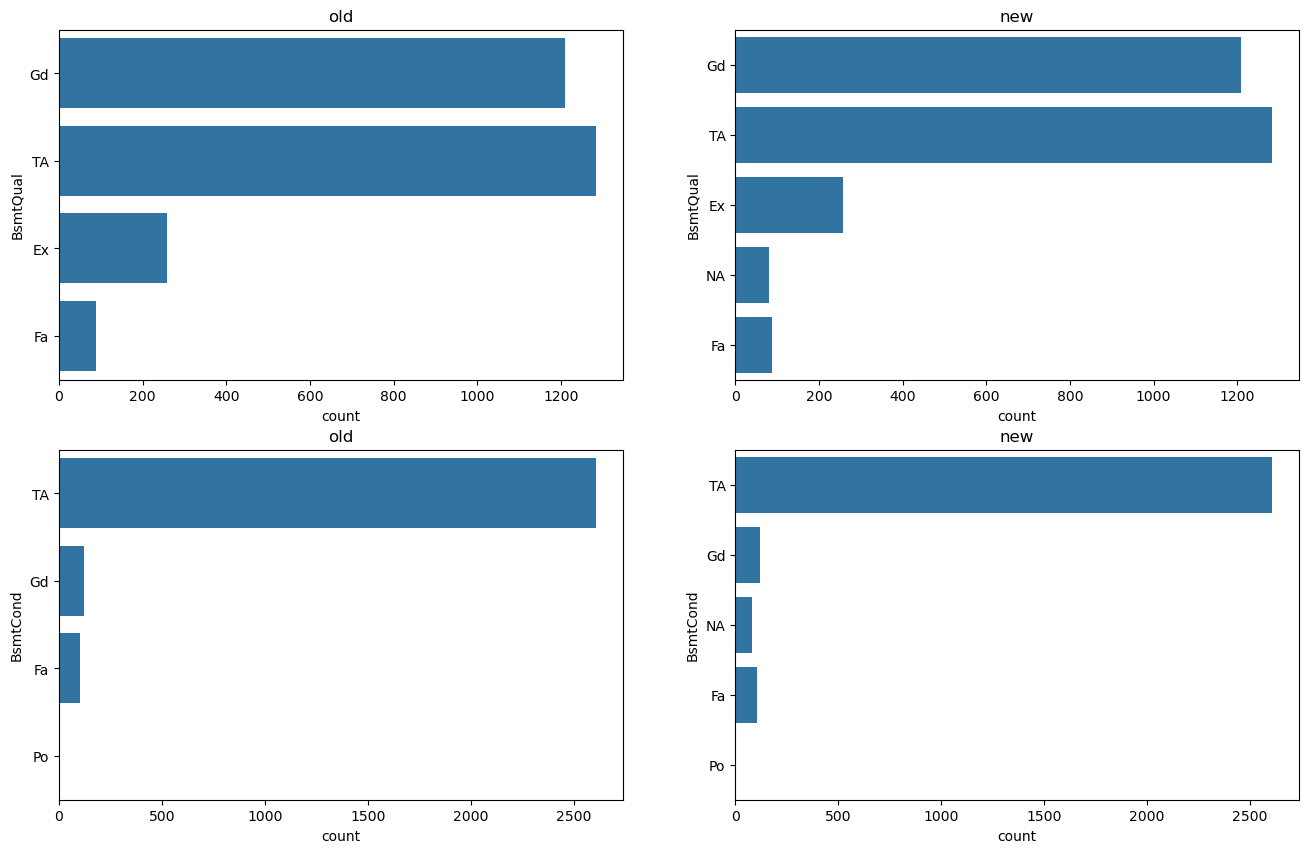

In [76]:
def oldnew(df, df_new, feature1, feature2, figsize = (16, 10)):
    plt.figure(figsize = figsize)
    plt.subplot(221)
    plt.title("old")
    sns.countplot(df[feature1])
    plt.subplot(222)
    plt.title("new")
    sns.countplot(df_mvi[feature1])
    plt.subplot(223)
    plt.title("old")
    sns.countplot(df[feature2])
    plt.subplot(224)
    plt.title("new")
    sns.countplot(df_mvi[feature2])
oldnew(df, df_mvi, "BsmtQual", "BsmtCond")


In [77]:
bsmtqual_mode = df["BsmtQual"].mode()[0]
df_mvi["BsmtQual"].replace(np.nan, bsmtqual_mode, inplace = True )
df_mvi["BsmtQual"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2234853317.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["BsmtQual"].replace(np.nan, bsmtqual_mode, inplace = True )


np.int64(0)

In [78]:
bsmtcond_mode = df["BsmtCond"].mode()[0]
bsmtcond_mode

'TA'

<Axes: xlabel='count', ylabel='BsmtQual'>

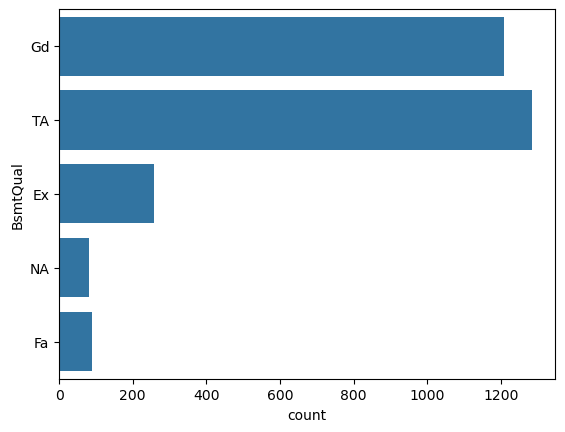

In [79]:
sns.countplot(df_mvi["BsmtQual"])

## handling basemet Values

In [80]:
"""
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665

BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517"""

'\nBsmtExposure     2.809181\nBsmtFinType1     2.706406\nBsmtFinType2     2.740665\n\nBsmtFinSF1       0.034258\nBsmtFinSF2       0.034258\nBsmtUnfSF        0.034258\nTotalBsmtSF      0.034258\nBsmtFullBath     0.068517\nBsmtHalfBath     0.068517'

In [81]:
cat_feature_V = ["BsmtExposure",
"BsmtFinType1",
"BsmtFinType2" ]   

num_feature_V = ["BsmtFinSF1",
"BsmtFinSF2", 
"BsmtUnfSF",   
"TotalBsmtSF", 
"BsmtFullBath",
"BsmtHalfBath"]



In [82]:
for feat in cat_feature_V:
    print(f"value of catgrey features {feat}: {df[feat].value_counts()}")

cat_feature_V

value of catgrey features BsmtExposure: BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64
value of catgrey features BsmtFinType1: BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64
value of catgrey features BsmtFinType2: BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64


['BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

In [83]:
cat_basm_cont = "NA"
for feat in cat_feature_V:
    df_mvi[feat].replace(np.nan, cat_basm_cont, inplace = True)
    

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\4122339208.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi[feat].replace(np.nan, cat_basm_cont, inplace = True)


In [84]:
df_mvi[cat_feature_V].isnull().sum()

BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

<Axes: ylabel='Id'>

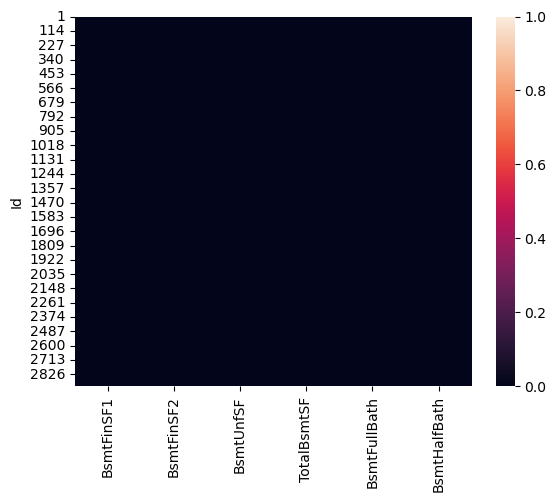

In [85]:
sns.heatmap(df[num_feature_V].isnull())

In [86]:
df_bsmt = df[cat_feature_V + num_feature_V]
df_bsmt[df_bsmt.isnull().any(axis=1)]

,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
Id,,,,,,,,,
18,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
40,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
91,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
103,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
157,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
183,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
260,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
333,No,GLQ,NaN,1124.0,479.0,1603.0,3206.0,1.0,0.0
343,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [87]:
df_mvi[num_feature_V].isnull().sum()

BsmtFinSF1      1
BsmtFinSF2      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
BsmtHalfBath    2
dtype: int64

In [88]:
bsmt_num_cont = 0
for feat in num_feature_V:
    df_mvi[feat].replace(np.nan, bsmt_num_cont, inplace = True)
    

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\3116048123.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi[feat].replace(np.nan, bsmt_num_cont, inplace = True)


In [89]:
df_mvi[num_feature_V].isnull().sum()

BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64

## handling Electrical = 0.034258 KitchenQual = 0.034258

In [90]:
df["Electrical"].value_counts()

Electrical
SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Electrical'>

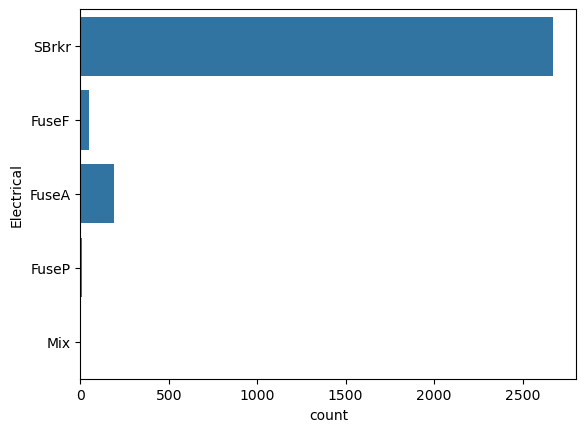

In [91]:
sns.countplot(df["Electrical"])

In [92]:
elictrical_value = df["Electrical"].mode()[0]
df_mvi["Electrical"].replace(np.nan, elictrical_value, inplace = True)
df_mvi["Electrical"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2286293357.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["Electrical"].replace(np.nan, elictrical_value, inplace = True)


np.int64(0)

<Axes: xlabel='count', ylabel='Electrical'>

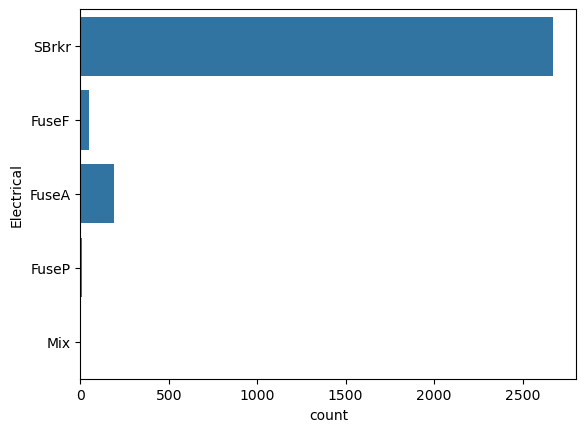

In [93]:
sns.countplot(df["Electrical"])

In [94]:
df["Electrical"].isnull().sum(), df_mvi["Electrical"].isnull().sum()

(np.int64(1), np.int64(0))

<Axes: xlabel='count', ylabel='KitchenQual'>

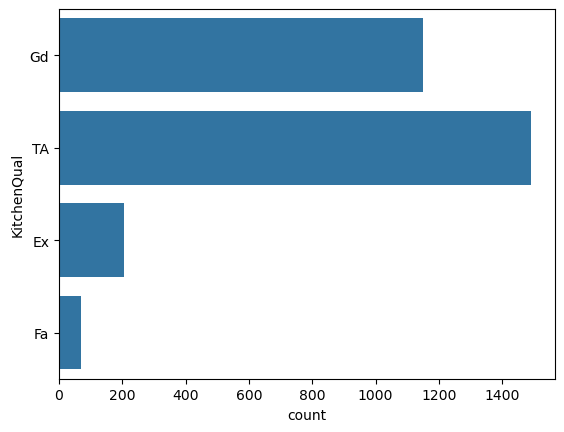

In [95]:
sns.countplot(df["KitchenQual"])

In [96]:
kitchenqual_mode = df["KitchenQual"].mode() [0]
df_mvi["KitchenQual"].replace(np.nan, kitchenqual_mode, inplace = True)
df_mvi["KitchenQual"].isnull().sum()
print("Mode of KitchenQual = ", kitchenqual_mode )

Mode of KitchenQual =  TA


C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2982546859.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["KitchenQual"].replace(np.nan, kitchenqual_mode, inplace = True)


<Axes: xlabel='count', ylabel='KitchenQual'>

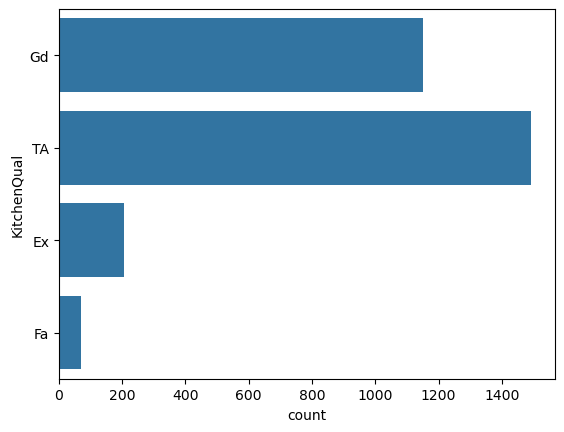

In [97]:
sns.countplot(df_mvi["KitchenQual"])

## Functional = 0.068517 FireplaceQu = 48.646797

In [98]:
df["Functional"].isnull().sum()

np.int64(2)

<Axes: xlabel='count', ylabel='Functional'>

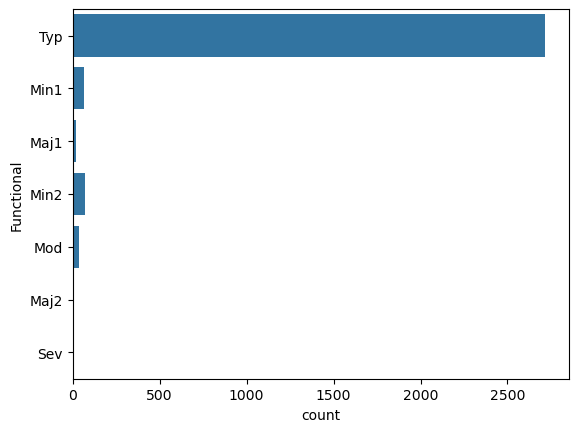

In [99]:
sns.countplot(df["Functional"])

In [100]:
functional_mode = df["Functional"].mode() [0]
df_mvi["Functional"].replace(np.nan, functional_mode, inplace = True)
df_mvi["Functional"].isnull().sum()

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\1759613245.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["Functional"].replace(np.nan, functional_mode, inplace = True)


np.int64(0)

In [101]:
df["FireplaceQu"].isnull().sum()

np.int64(1420)

<Axes: xlabel='count', ylabel='FireplaceQu'>

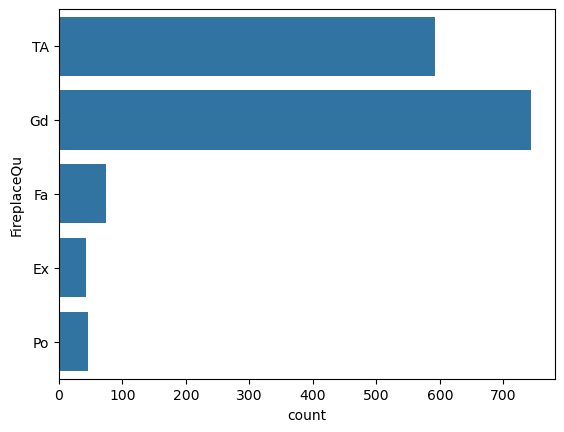

In [102]:
sns.countplot(df["FireplaceQu"])

In [103]:
df["FireplaceQu"].value_counts()

FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64

In [104]:
fireplacequ_cont = "NA"
df_mvi["FireplaceQu"].replace(np.nan, fireplacequ_cont, inplace = True)

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\2955962568.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi["FireplaceQu"].replace(np.nan, fireplacequ_cont, inplace = True)


In [105]:
df_mvi["FireplaceQu"].value_counts()

FireplaceQu
NA    1420
Gd     744
TA     592
Fa      74
Po      46
Ex      43
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='FireplaceQu'>

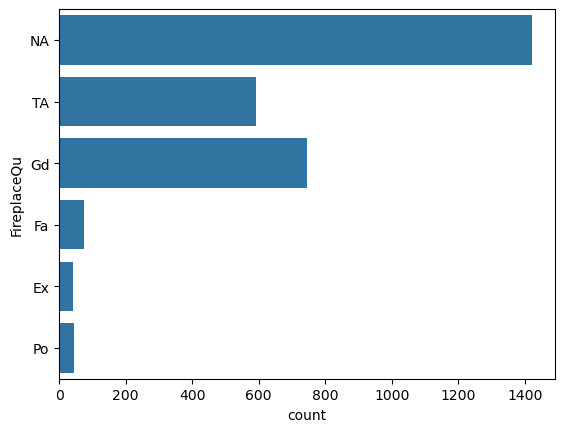

In [106]:
sns.countplot(df_mvi["FireplaceQu"])

In [107]:
##fireplacequ
df_mvi["FireplaceQu"].isnull().sum()

np.int64(0)

## handling PoolQC          99.657417
## handling Fence           80.438506
## handling MiscFeature     96.402878
## handling SaleType         0.034258

In [108]:
more_cat_feat = ["PoolQC",    
"Fence",
"MiscFeature",
"SaleType"]

for Ifeat in more_cat_feat:
    print(f"Value of this features: {Ifeat}" , df[Ifeat].value_counts())

Value of this features: PoolQC PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64
Value of this features: Fence Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64
Value of this features: MiscFeature MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64
Value of this features: SaleType SaleType
WD       2525
New       239
COD        87
ConLD      26
CWD        12
ConLI       9
ConLw       8
Oth         7
Con         5
Name: count, dtype: int64


In [109]:
for feat in more_cat_feat:
    df_mvi[feat].fillna("NA", inplace=True)

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\1658125412.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi[feat].fillna("NA", inplace=True)


<Axes: xlabel='count', ylabel='MiscFeature'>

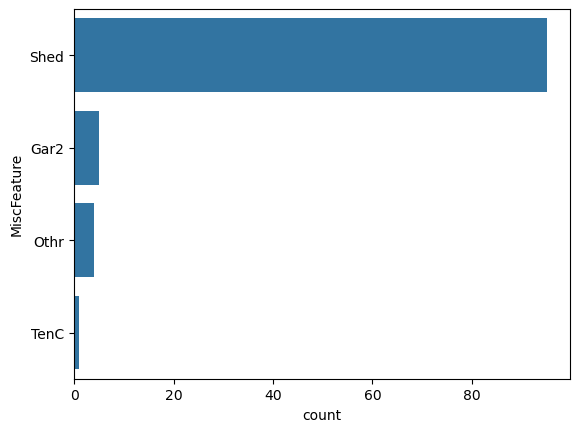

In [110]:
sns.countplot(df["MiscFeature"])

<Axes: xlabel='count', ylabel='MiscFeature'>

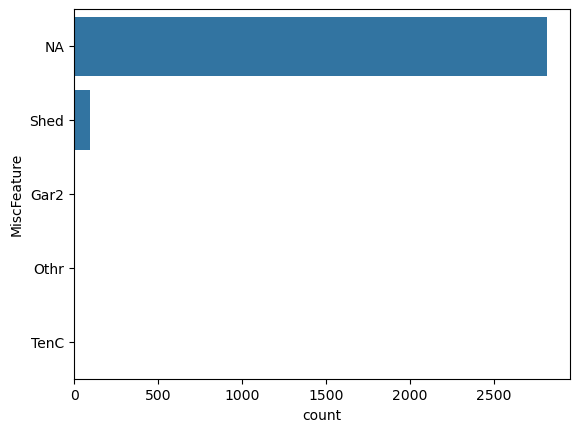

In [111]:
sns.countplot(df_mvi["MiscFeature"])

<Axes: xlabel='count', ylabel='Fence'>

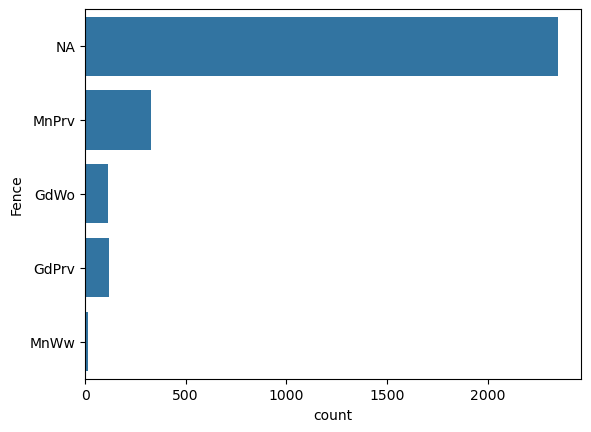

In [112]:
sns.countplot(df_mvi["Fence"])

## Handling GarageType       5.378554
## Handling GarageFinish     5.447071
## Handling GarageQual       5.447071  
## Handling GarageCond       5.447071
## Handling 
## Handling GarageCars       0.034258 ##float
## Handling GarageArea       0.034258  ##float
## Handling GarageYrBlt      5.447071 ## float

In [113]:
for feat in more_cat_feat:
    df_mvi[feat].fillna("NA", inplace=True)

In [114]:
cat_feature_list = ["GarageType",
"GarageCond",
"GarageFinish", 
"GarageQual"]  

int_feature_list = ["GarageCars",
"GarageArea",
"GarageYrBlt"]    

In [115]:
for Ifeat in cat_feature_list:
    print(f"Value of this features: {Ifeat}" , df[Ifeat].value_counts())

Value of this features: GarageType GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64
Value of this features: GarageCond GarageCond
TA    2654
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64
Value of this features: GarageFinish GarageFinish
Unf    1230
RFn     811
Fin     719
Name: count, dtype: int64
Value of this features: GarageQual GarageQual
TA    2604
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64


In [116]:
df_int = df[cat_feature_list]
df_int[df_int.isnull().any(axis=1)]

,GarageType,GarageCond,GarageFinish,GarageQual
Id,,,,
40,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN
100,NaN,NaN,NaN,NaN
109,NaN,NaN,NaN,NaN
126,NaN,NaN,NaN,NaN
128,NaN,NaN,NaN,NaN


In [117]:
cat_cont = "NA"
for feat in cat_feature_list:
    df_mvi[feat].replace(np.nan, cat_cont, inplace = True)
    

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\3867239921.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi[feat].replace(np.nan, cat_cont, inplace = True)


In [118]:
df_int = df[cat_feature_list]
df_int[df_int.isnull().any(axis=1)]

,GarageType,GarageCond,GarageFinish,GarageQual
Id,,,,
40,NaN,NaN,NaN,NaN
49,NaN,NaN,NaN,NaN
79,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN
100,NaN,NaN,NaN,NaN
109,NaN,NaN,NaN,NaN
126,NaN,NaN,NaN,NaN
128,NaN,NaN,NaN,NaN


In [119]:
df[cat_feature_list].isnull().sum()

GarageType      157
GarageCond      159
GarageFinish    159
GarageQual      159
dtype: int64

In [120]:
df_mvi[cat_feature_list].isnull().sum()

GarageType      0
GarageCond      0
GarageFinish    0
GarageQual      0
dtype: int64

In [121]:
int_cont = 0
for feat in int_feature_list:
    df_mvi[feat].replace(np.nan, int_cont, inplace = True)
    

C:\Users\M Irfan Shahid\AppData\Local\Temp\ipykernel_9516\3390838078.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mvi[feat].replace(np.nan, int_cont, inplace = True)


In [122]:
df[int_feature_list].isnull().sum()

GarageCars       1
GarageArea       1
GarageYrBlt    159
dtype: int64

In [123]:
df_mvi[int_feature_list].isnull().sum()

GarageCars     0
GarageArea     0
GarageYrBlt    0
dtype: int64

In [124]:
df_mvi.isnull().any(axis=1).sum()

np.int64(1459)

## Feature Transformation
# convert numarical into categorycal 

In [125]:
for_con_num = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
for feat in for_con_num:
    print(f"{feat}: data types = {df_mvi[feat].dtype}")

MSSubClass: data types = int64
YearBuilt: data types = int64
YearRemodAdd: data types = int64
GarageYrBlt: data types = float64
MoSold: data types = int64
YrSold: data types = int64


In [126]:
print(calendar.THURSDAY)

3


In [127]:
df["MoSold"].value_counts()

MoSold
6     503
7     446
5     394
4     279
8     233
3     232
10    173
9     158
11    142
2     133
1     122
12    104
Name: count, dtype: int64

In [128]:
df_mvi["MoSold"].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6])

In [129]:
df_mvi["MoSold"] = df_mvi["MoSold"].apply(lambda x: calendar.month_abbr[x])
df_mvi["MoSold"]

Id
1       Feb
2       May
3       Sep
4       Feb
5       Dec
6       Oct
7       Aug
8       Nov
9       Apr
10      Jan
11      Feb
12      Jul
13      Sep
14      Aug
15      May
16      Jul
17      Mar
18      Oct
19      Jun
20      May
21      Nov
22      Jun
23      Sep
24      Jun
25      May
26      Jul
27      May
28      May
29      Dec
30      May
31      Jul
32      Jun
33      Jan
34      Apr
35      Aug
36      Sep
37      Jun
38      Oct
39      Jan
40      Jun
41      Dec
42      Jul
43      Dec
44      Jul
45      May
46      Feb
47      Aug
48      Jul
49      Jun
50      Jan
51      Jul
52      Sep
53      May
54      Nov
55      Feb
56      Jul
57      Aug
58      Aug
59      Oct
60      Jan
61      May
62      Mar
63      Oct
64      Apr
65      Feb
66      Oct
67      Jul
68      Jun
69      Jun
70      Jul
71      Feb
72      Jun
73      Dec
74      May
75      May
76      Nov
77      Apr
78      Jan
79      Apr
80      May
81      Jun
82      Mar
83      Oct
8

In [130]:
df_mvi["MoSold"].unique()

array(['Feb', 'May', 'Sep', 'Dec', 'Oct', 'Aug', 'Nov', 'Apr', 'Jan',
       'Jul', 'Mar', 'Jun'], dtype=object)

In [131]:
df_mvi["MoSold"].value_counts()

MoSold
Jun    503
Jul    446
May    394
Apr    279
Aug    233
Mar    232
Oct    173
Sep    158
Nov    142
Feb    133
Jan    122
Dec    104
Name: count, dtype: int64

In [132]:
for feat in for_con_num:
    df_mvi[feat] = df_mvi[feat].astype(str)

In [133]:
for feat in for_con_num:
    print(f"{feat}: data types = {df_mvi[feat].dtype}")

MSSubClass: data types = object
YearBuilt: data types = object
YearRemodAdd: data types = object
GarageYrBlt: data types = object
MoSold: data types = object
YrSold: data types = object


## Now We Use Ordinal Encoding for Object

In [134]:
ordinal_enco_v = [
"ExterQual", 
"ExterCond", 
"BsmtQual",
"BsmtCond",
"BsmtExposure",
"BsmtFinType1",
"BsmtFinType2",
"HeatingQC",
"KitchenQual",
"FireplaceQu",
"GarageQual",
"GarageCond",
"PoolQC"  ,
"Functional",
"GarageFinish",
"PaveDrive",
"Utilities"]
print ("total number of feature which convert to ordinal", len(ordinal_enco_v))

total number of feature which convert to ordinal 17


In [135]:
df_mvi["ExterQual"].value_counts()

ExterQual
TA    1798
Gd     979
Ex     107
Fa      35
Name: count, dtype: int64

In [136]:
df_mvi["ExterQual"].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [137]:
df_mvi["ExterQual"] = df_mvi["ExterQual"].astype (
    CategoricalDtype (
        categories = ["Po","Fa","TA","Gd", "Ex"], 
        ordered = True
    )
).cat.codes

In [138]:
df_mvi["ExterQual"].unique()

array([3, 2, 4, 1], dtype=int8)

In [139]:
df_mvi["ExterQual"].value_counts()

ExterQual
2    1798
3     979
4     107
1      35
Name: count, dtype: int64

In [140]:
df_mvi["ExterCond"].value_counts()

ExterCond
TA    2538
Gd     299
Fa      67
Ex      12
Po       3
Name: count, dtype: int64

In [141]:
df_mvi["ExterCond"] = df_mvi["ExterCond"].astype (
    CategoricalDtype (
        categories = ["Po","Fa","TA","Gd", "Ex"], 
        ordered = True
    )
).cat.codes

In [142]:
df_mvi["ExterCond"].value_counts()

ExterCond
2    2538
3     299
1      67
4      12
0       3
Name: count, dtype: int64

In [143]:
df_mvi["BsmtQual"].value_counts()

BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
NA      81
Name: count, dtype: int64

In [144]:
df_mvi["BsmtQual"] = df_mvi["BsmtQual"].astype (
    CategoricalDtype (
        categories = ["NA","Po","Fa","TA","Gd", "Ex"], 
        ordered = True
    )
).cat.codes

In [145]:
df_mvi["BsmtQual"].value_counts()

BsmtQual
3    1283
4    1209
5     258
2      88
0      81
Name: count, dtype: int64

In [146]:
df_mvi["BsmtCond"].value_counts()

BsmtCond
TA    2606
Gd     122
Fa     104
NA      82
Po       5
Name: count, dtype: int64

In [147]:
df_mvi["BsmtCond"] = df_mvi["BsmtCond"].astype(
    CategoricalDtype( 
        categories = ["NA","Po","Fa","TA","Gd", "Ex"],
        ordered = True
    )
).cat.codes

In [148]:
df_mvi["BsmtCond"].value_counts()

BsmtCond
3    2606
4     122
2     104
0      82
1       5
Name: count, dtype: int64

In [149]:
df_mvi["BsmtExposure"].value_counts()

BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
NA      82
Name: count, dtype: int64

In [150]:
df_mvi["BsmtExposure"] = df_mvi["BsmtExposure"].astype(
    CategoricalDtype( 
        categories = ["NA","No","Mn","Av","Gd"],
        ordered = True
    )
).cat.codes

In [151]:
df_mvi["BsmtExposure"].value_counts()

BsmtExposure
1    1904
3     418
4     276
2     239
0      82
Name: count, dtype: int64

In [152]:
df_mvi["BsmtFinType1"].value_counts()

BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
NA      79
Name: count, dtype: int64

In [153]:
df_mvi["BsmtFinType1"] = df_mvi["BsmtFinType1"].astype(
    CategoricalDtype( 
        categories = ["NA","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
        ordered = True
    )
).cat.codes

In [154]:
df_mvi["BsmtFinType1"].value_counts()

BsmtFinType1
1    851
6    849
5    429
3    288
4    269
2    154
0     79
Name: count, dtype: int64

In [155]:
df_mvi["BsmtFinType2"].value_counts()

BsmtFinType2
Unf    2493
Rec     105
LwQ      87
NA       80
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64

In [156]:
df_mvi["BsmtFinType2"] = df_mvi["BsmtFinType2"].astype(
    CategoricalDtype( 
        categories = ["NA","Unf","LwQ","Rec","BLQ","ALQ","GLQ"],
        ordered = True
    )
).cat.codes

In [157]:
df_mvi["BsmtFinType2"].value_counts()

BsmtFinType2
1    2493
3     105
2      87
0      80
4      68
5      52
6      34
Name: count, dtype: int64

In [158]:
df_mvi["HeatingQC"] = df_mvi["HeatingQC"].astype(CategoricalDtype(categories = ["Po", "Fa", "TA", "Gd", "Ex"], ordered = True)).cat.codes
df_mvi["KitchenQual"] = df_mvi["KitchenQual"].astype(CategoricalDtype(categories = ["Po", "Fa", "TA", "Gd", "Ex"], ordered = True)).cat.codes
df_mvi["FireplaceQu"] = df_mvi["FireplaceQu"].astype(CategoricalDtype(categories = ["NA","Po", "Fa", "TA", "Gd", "Ex"], ordered = True)).cat.codes
df_mvi["GarageQual"] = df_mvi["GarageQual"].astype(CategoricalDtype(categories = ["NA","Po", "Fa", "TA", "Gd", "Ex"], ordered = True)).cat.codes
df_mvi["GarageCond"] = df_mvi["GarageCond"].astype(CategoricalDtype(categories = ["NA","Po", "Fa", "TA", "Gd", "Ex"], ordered = True)).cat.codes
df_mvi["PoolQC"] = df_mvi["PoolQC"].astype(CategoricalDtype(categories = ["NA","Fa", "TA", "Gd", "Ex"], ordered = True)).cat.codes
df_mvi["Functional"] = df_mvi["Functional"].astype(CategoricalDtype(categories = ["Sal", "Sev", "Maj2", "Maj1","Mod", "Min2", "Min1", "Typ"], ordered = True)).cat.codes
df_mvi["GarageFinish"] = df_mvi["GarageFinish"].astype(CategoricalDtype(categories = ["NA", "Unf", "RFn", "Fin"], ordered = True)).cat.codes
df_mvi["PavedDrive"] = df_mvi["PavedDrive"].astype(CategoricalDtype(categories = ["N", "P", "Y"], ordered = True)).cat.codes
df_mvi["Utilities"] = df_mvi["Utilities"].astype(CategoricalDtype(categories = ["ELO", "NoSeWa", "NoSewr", "AllPub"], ordered = True)).cat.codes

## Handling MasVnrArea

In [159]:
df_mvi["MasVnrArea"].isnull().sum()

np.int64(0)

In [160]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2919 non-null   object 
 1   MSZoning       2919 non-null   object 
 2   LotFrontage    2919 non-null   float64
 3   LotArea        2919 non-null   int64  
 4   Street         2919 non-null   object 
 5   Alley          2919 non-null   object 
 6   LotShape       2919 non-null   object 
 7   LandContour    2919 non-null   object 
 8   Utilities      2919 non-null   int8   
 9   LotConfig      2919 non-null   object 
 10  LandSlope      2919 non-null   object 
 11  Neighborhood   2919 non-null   object 
 12  Condition1     2919 non-null   object 
 13  Condition2     2919 non-null   object 
 14  BldgType       2919 non-null   object 
 15  HouseStyle     2919 non-null   object 
 16  OverallQual    2919 non-null   int64  
 17  OverallCond    2919 non-null   int64  
 18  YearBuilt    

In [161]:
# Koi -1 to nahi aaya?
ordinal_features = ["BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual",
                    "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
                    "Functional", "GarageFinish", "PavedDrive", "Utilities"]

for feat in ordinal_features:
    neg = (df_mvi[feat] == -1).sum()
    if neg > 0:
        print(f"⚠️  {feat}: {neg} values -1 hain — spelling check karo!")

In [162]:
df_mvi["PavedDrive"].value_counts()

PavedDrive
2    2641
0     216
1      62
Name: count, dtype: int64

## ONE HOT ENCODING for nomial Categorical data

In [163]:
df_encode = df_mvi.copy()

object_feature = df_encode.select_dtypes(include = "object" ).columns.tolist()
print("Total Object categorical Features: ", len(object_feature))

print("Features: \n", object_feature)

Total Object categorical Features:  32
Features: 
 ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'GarageYrBlt', 'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [164]:
print ("Data before encode", df_encode.shape)
df_encode = pd.get_dummies(df_encode,
                           columns = object_feature,
                           prefix = object_feature,
                           drop_first = True )
print ("Data after encode", df_encode.shape)

Data before encode (2919, 80)
Data after encode (2919, 513)


In [165]:
df_encode.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 1 to 2919
Columns: 513 entries, LotFrontage to SaleCondition_Partial
dtypes: bool(465), float64(11), int64(20), int8(17)
memory usage: 2.1 MB


In [166]:
df_encode.select_dtypes(include = "object" ).columns.tolist()

[]

In [167]:
df_encode.shape

(2919, 513)

In [168]:
len_train = df_train.shape[0]
len_train

1460

In [169]:
X_train = df_encode[:len_train].drop("SalePrice", axis = 1)
y_train = df_encode["SalePrice"][:len_train]
X_test = df_encode[len_train:].drop("SalePrice", axis = 1)

print("Shape of X_train data: ", X_train.shape)
print("Shape of y_train data: ", y_train.shape)
print("Shape of X_test data: ", X_test.shape)

Shape of X_train data:  (1460, 512)
Shape of y_train data:  (1460,)
Shape of X_test data:  (1459, 512)


In [170]:
X_train.isnull().sum()

LotFrontage              0
LotArea                  0
Utilities                0
OverallQual              0
OverallCond              0
MasVnrArea               0
ExterQual                0
ExterCond                0
BsmtQual                 0
BsmtCond                 0
BsmtExposure             0
BsmtFinType1             0
BsmtFinSF1               0
BsmtFinType2             0
BsmtFinSF2               0
BsmtUnfSF                0
TotalBsmtSF              0
HeatingQC                0
1stFlrSF                 0
2ndFlrSF                 0
LowQualFinSF             0
GrLivArea                0
BsmtFullBath             0
BsmtHalfBath             0
FullBath                 0
HalfBath                 0
BedroomAbvGr             0
KitchenAbvGr             0
KitchenQual              0
TotRmsAbvGrd             0
Functional               0
Fireplaces               0
FireplaceQu              0
GarageFinish             0
GarageCars               0
GarageArea               0
GarageQual               0
G

In [171]:
sc = StandardScaler()
sc.fit(X_train)
# formula z = (x-u)/s

X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [172]:
## Carry forward for deployment 
#sc.mean
# sc.n_features_in_
# sc.n_samples_seen_
# sc.with_mean
# sc.scale_
# sc.with_std
# sc.var_

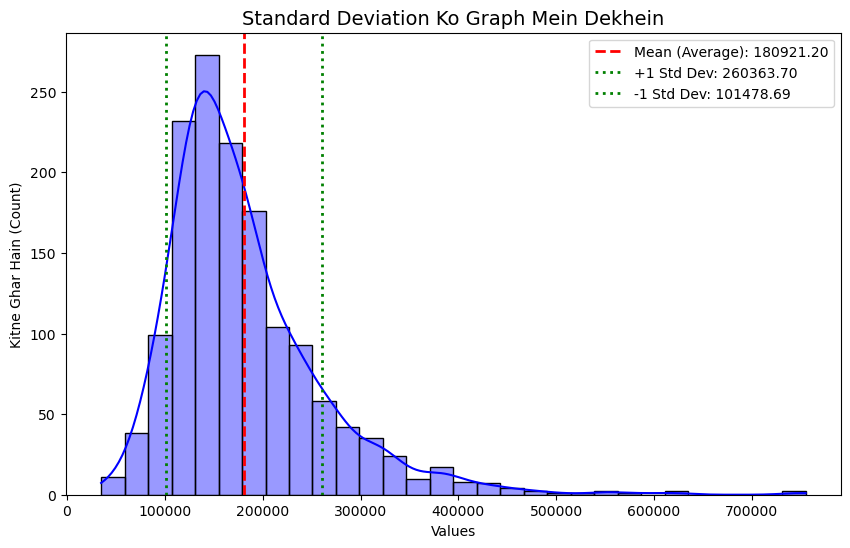

In [173]:
data_column = df_encode["SalePrice"] 

# Mean (Average) aur Standard Deviation calculate karte hain
mean_val = data_column.mean()
std_val = data_column.std()

# 2. Graph banana shuru karte hain
plt.figure(figsize=(10, 6))

# Histogram banayein jo data ki shape dikhaye ga
sns.histplot(data_column, kde=True, color="blue", bins=30, alpha=0.4)

# Graph ke beech mein AVERAGE (Mean) ki seedhi line lagate hain (Red color mein)
plt.axvline(mean_val, color="red", linestyle="dashed", linewidth=2, label=f"Mean (Average): {mean_val:.2f}")

# Average se AK standard deviation aagay aur peeche lines lagate hain (Green color mein)
plt.axvline(mean_val + std_val, color="green", linestyle="dotted", linewidth=2, label=f"+1 Std Dev: {mean_val + std_val:.2f}")
plt.axvline(mean_val - std_val, color="green", linestyle="dotted", linewidth=2, label=f"-1 Std Dev: {mean_val - std_val:.2f}")

# Labels aur Title lagate hain
plt.title("Standard Deviation Ko Graph Mein Dekhein", fontsize=14)
plt.xlabel("Values")
plt.ylabel("Kitne Ghar Hain (Count)")
plt.legend()

# Graph show karein
plt.show()

## Train ML Models 

In [174]:
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor

In [175]:
svr = SVR()
Ir = LinearRegression()
sgdr = SGDRegressor()
knr = KNeighborsRegressor()
gpr = GaussianProcessRegressor()
dtr = DecisionTreeRegressor()
gbr = GradientBoostingRegressor()
rfr = RandomForestRegressor()
xgbr = XGBRegressor()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
elastic = ElasticNet(alpha=1.0)
adabr = AdaBoostRegressor(random_state=42)
extr = ExtraTreesRegressor(random_state=42)
mlpr = MLPRegressor(max_iter=2000, random_state=42)

In [176]:
models = {"f":["Decision TreeRegressor", dtr],
          "g":["Gradient Boosting Regressor", gbr],
          "h":["Random Forest Regressor", rfr],
          "i": ["XGBRegressor", xgbr]
          }

In [177]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score

def test_model(model, X_train=X_train, y_train=y_train):

    cv = KFold(n_splits = 10, shuffle = True, random_state = 45)
    r2 = make_scorer(r2_score)
    r2_val_score = cross_val_score (model, X_train, y_train, cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score

In [178]:
models_score = []
for model in models:
    print("Training model: ", models [model][0])
    score = test_model(models [model] [1], X_train, y_train)
    print("Score of model: ", score)
    models_score.append([models [model][0], score[0]])

Training model:  Decision TreeRegressor
Score of model:  [np.float64(0.7114800809778846)]
Training model:  Gradient Boosting Regressor
Score of model:  [np.float64(0.8800398861734655)]
Training model:  Random Forest Regressor
Score of model:  [np.float64(0.8484899901460141)]
Training model:  XGBRegressor
Score of model:  [np.float64(0.8462113154079448)]
